# Miesięczne wskaźniki KPI sieci telekomunikacyjnej: słupki zużycia danych z liniami ARPU i odpływu klientów (PROC GBARLINE)

## Podsumowanie wykonawcze

Ten notatnik używa **PROC GBARLINE** do połączenia pionowego wykresu słupkowego miesięcznego zużycia danych mobilnych z nałożonymi wykresami liniowymi ARPU, odpływu klientów (churn) i zgłoszeń serwisowych — klasyczny pulpit KPI "dwuosiowy", jaki buduje analityk telekomunikacyjny, aby sprawdzić, czy rosnące zużycie faktycznie przekłada się na przychód i retencję. Notatnik generuje wewnętrznie syntetyczne rekordy na poziomie abonenta, a następnie wykorzystuje instrukcje BAR i LINE z podgrupami, niestandardowymi prawymi osiami, symbolami odniesienia i legendami.

## Źródła danych

**Zbiór danych: `telco_kpi`** — syntetyczne rekordy na poziomie abonent-miesiąc (4 miesiące x 3 poziomy planu x 8 abonentów = 96 wierszy), wygenerowane wewnętrznie za pomocą `call streaminit(20260531)`. Panel utrzymano na 96 wierszach, aby zmieścił się komfortowo w limicie 100 obserwacji trybu bez licencji, pozostawiając każdy miesiąc i poziom planu w pełni obsadzony.

| Zmienna | Typ | Opis |
|----------|------|-------------|
| `month`  | Znak | Etykieta miesiąca kalendarzowego (sty–kwi) |
| `plan`   | Znak | Poziom planu: Przedpłacony, Abonamentowy, Rodzinny |
| `data_gb`| Liczb.  | Miesięczne zużycie danych mobilnych, w GB (rozkład gamma, z łagodnym wzrostem sezonowym i powolnym wzrostem) |
| `arpu`   | Liczb.  | Średni przychód na użytkownika, w USD (rośnie z poziomem planu i w kolejnych miesiącach) |
| `churn`  | Liczb.  | Miesięczna flaga odpływu (0/1, Bernoulliego; wyższa wcześnie w okresie i na tańszych poziomach) |
| `tickets`| Liczb.  | Otwarte zgłoszenia serwisowe (zliczenie Poissona) |

# Miesięczne wskaźniki KPI sieci telekomunikacyjnej za pomocą PROC GBARLINE

Operatorzy telekomunikacyjni żyją i umierają garstką miesięcznych wskaźników KPI: ile **danych** zużywają abonenci, jakie **ARPU** (średni przychód na użytkownika) generuje to zużycie, ilu klientów **odchodzi** (churn) i jakie obciążenie **zgłoszeniami serwisowymi** za tym stoi. Te miary żyją na bardzo różnych skalach — gigabajty, dolary i małe zliczenia — więc wykreślenie ich na jednej osi odpowiedzi ukrywa historię.

`PROC GBARLINE` jest zbudowany dokładnie do tego: rysuje pionowy wykres **słupkowy** na lewej osi i nakłada jeden lub więcej wykresów **liniowych** na niezależnej prawej osi. W tym notatniku budujemy pulpit zużycie-a-przychód, a następnie stopniowo dokładamy podgrupy na poziomie planu, niestandardową prawą oś i nakładki wielu linii.

## Krok 1 — Wygenerowanie syntetycznych danych abonent-miesiąc

Poniższy krok danych fabrykuje realistyczny panel: 4 miesiące (sty–kwi) w 3 poziomach planu (Przedpłacony, Abonamentowy, Rodzinny) po 8 abonentów każdy, co daje w sumie 96 wierszy. Ustalamy generator liczb losowych za pomocą `call streaminit` dla powtarzalności i losujemy każdy KPI z rozkładu odpowiedniego dla danej dziedziny:

- **Zużycie danych** z rozkładu gamma z łagodnym wzrostem sezonowym i powolnym wzrostem miesiąc do miesiąca.
- **ARPU** rosnące z poziomem planu i w kolejnych miesiącach, z szumem normalnym.
- **Odpływ** jako flaga Bernoulliego wyższa wcześnie w okresie i na tańszych poziomach.
- **Zgłoszenia serwisowe** jako zliczenia Poissona, nieco cięższe na początku.

Żadne pliki zewnętrzne nie są odczytywane — wszystko jest samowystarczalne, a panel 96 wierszy mieści się w nielicencjonowanym limicie 100 obserwacji, więc każdy miesiąc i poziom planu się renderuje.

In [1]:
DANE telco_kpi;
    CALL streaminit(20260531);
    DŁUGOŚĆ month $3 plan $16;
    TABLICA mname[4] $3 _temporary_
        ('Sty' 'Lut' 'Mar' 'Kwi');
    POWTÓRZ mi = 1 TO 4;
        month = mname[mi];
        /* łagodny wzrost sezonowy i powolny wzrost danych */
        season = 1 + 0.10*sin((mi-1)/12*2*3.14159);
        POWTÓRZ plan_i = 1 TO 3;
            JEŚLI plan_i = 1 WTEDY plan = 'Przedpłacony';
            PRZECIWNIE JEŚLI plan_i = 2 WTEDY plan = 'Abonamentowy';
            PRZECIWNIE plan = 'Rodzinny';
            POWTÓRZ rep = 1 TO 8;
                /* miesięczne zużycie danych mobilnych (GB) */
                data_gb = rand('gamma', 4) * 3 * season
                          + (mi * 0.4);
                /* średni przychód na użytkownika ($) */
                arpu = 28 + 6*plan_i + rand('normal', 0, 4)
                       + mi*0.3;
                /* miesięczna flaga odpływu, wyższa wcześnie w roku */
                churn = rand('bernoulli',
                             0.18 - 0.03*plan_i + 0.02*(4-mi));
                /* otwarte zgłoszenia serwisowe */
                tickets = rand('poisson', 1.6 + 0.15*(4-mi));
                WYJŚCIE;
            KONIEC;
        KONIEC;
    KONIEC;
    USUŃ mi plan_i rep season mname:;
WYKONAJ;


NOTE: DATA telco_kpi


NOTE: Wrote telco_kpi (96 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Krok 2 — Podstawowy pulpit: słupki zużycia + linia ARPU

To jest kanoniczny wzorzec `GBARLINE`. Instrukcja `BAR` wykreśla średnie miesięczne zużycie danych (`SUMVAR=data_gb TYPE=mean`), a pojedyncza instrukcja `LINE` nakłada średnie ARPU na prawą oś (`STAT=mean TYPE=join`). Włączamy ODS Graphics i nadajemy wykresowi dwuliniowy tytuł. `COUTLINE=` i `WIDTH=` porządkują słupki.

                                       Miesięczne zużycie danych mobilnych i ARPU                                       
                                   Syntetyczne wskaźniki KPI sieci telekomunikacyjnej                                   




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Miesięczne zużycie danych mobilnych i ARPU.
NOTE: Option TITLE2 changed to Syntetyczne wskaźniki KPI sieci telekomunikacyjnej.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


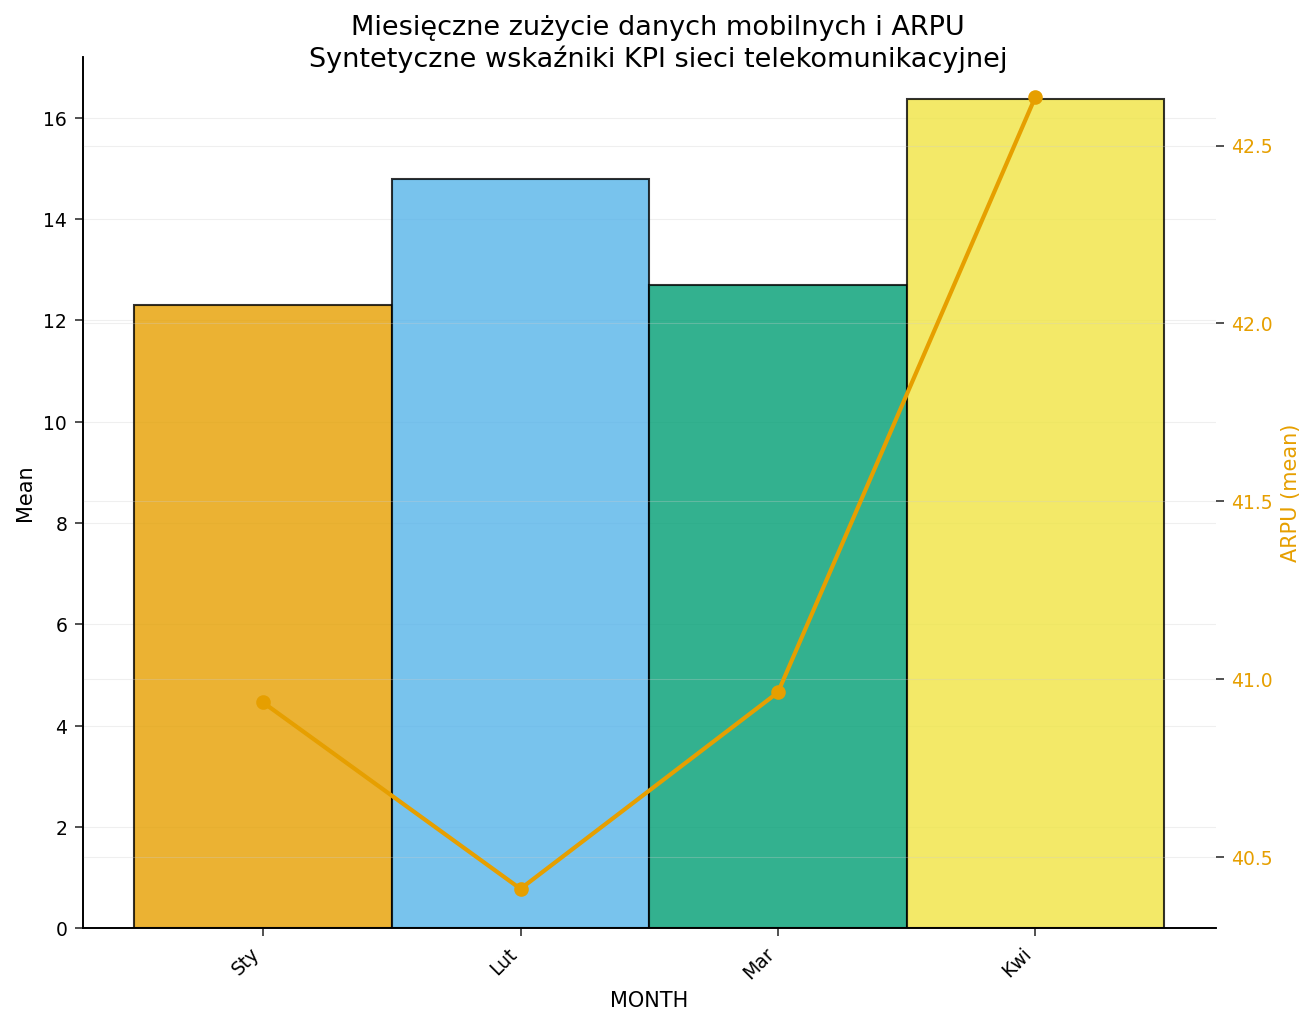

In [2]:
ODS GRAPHICS ON;
TYTUŁ 'Miesięczne zużycie danych mobilnych i ARPU';
title2 'Syntetyczne wskaźniki KPI sieci telekomunikacyjnej';

PROCEDURA gbarline DANE=telco_kpi;
    bar month / SUMVAR=data_gb type=mean
                coutline=black WIDTH=6;
    line arpu / STAT=mean type=JOIN;
    ETYKIETA month="Miesiąc" data_gb="Zużycie danych (GB)" arpu="ARPU ($)";
WYKONAJ;

## Krok 3 — Rozbicie zużycia wg planu, nałożenie odpływu

Zastąpienie `TYPE=mean` przez `TYPE=sum` i dodanie `SUBGROUP=plan` układa słupek każdego miesiąca wg poziomu planu, więc widać, który segment napędza łączny wolumen. Nałożona instrukcja `LINE` wykreśla teraz miesięczną **liczbę** zdarzeń odpływu jako wykres igłowy (`STAT=sum TYPE=needle`) — pionowe kolce, które naturalnie czyta się jako dyskretne zliczenia zdarzeń, a nie gładki trend.

                            Wolumen danych wg planu z miesięcznym odpływem klientów (churn)                             
                                   Syntetyczne wskaźniki KPI sieci telekomunikacyjnej                                   




NOTE: Option TITLE changed to Wolumen danych wg planu z miesięcznym odpływem klientów (churn).
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


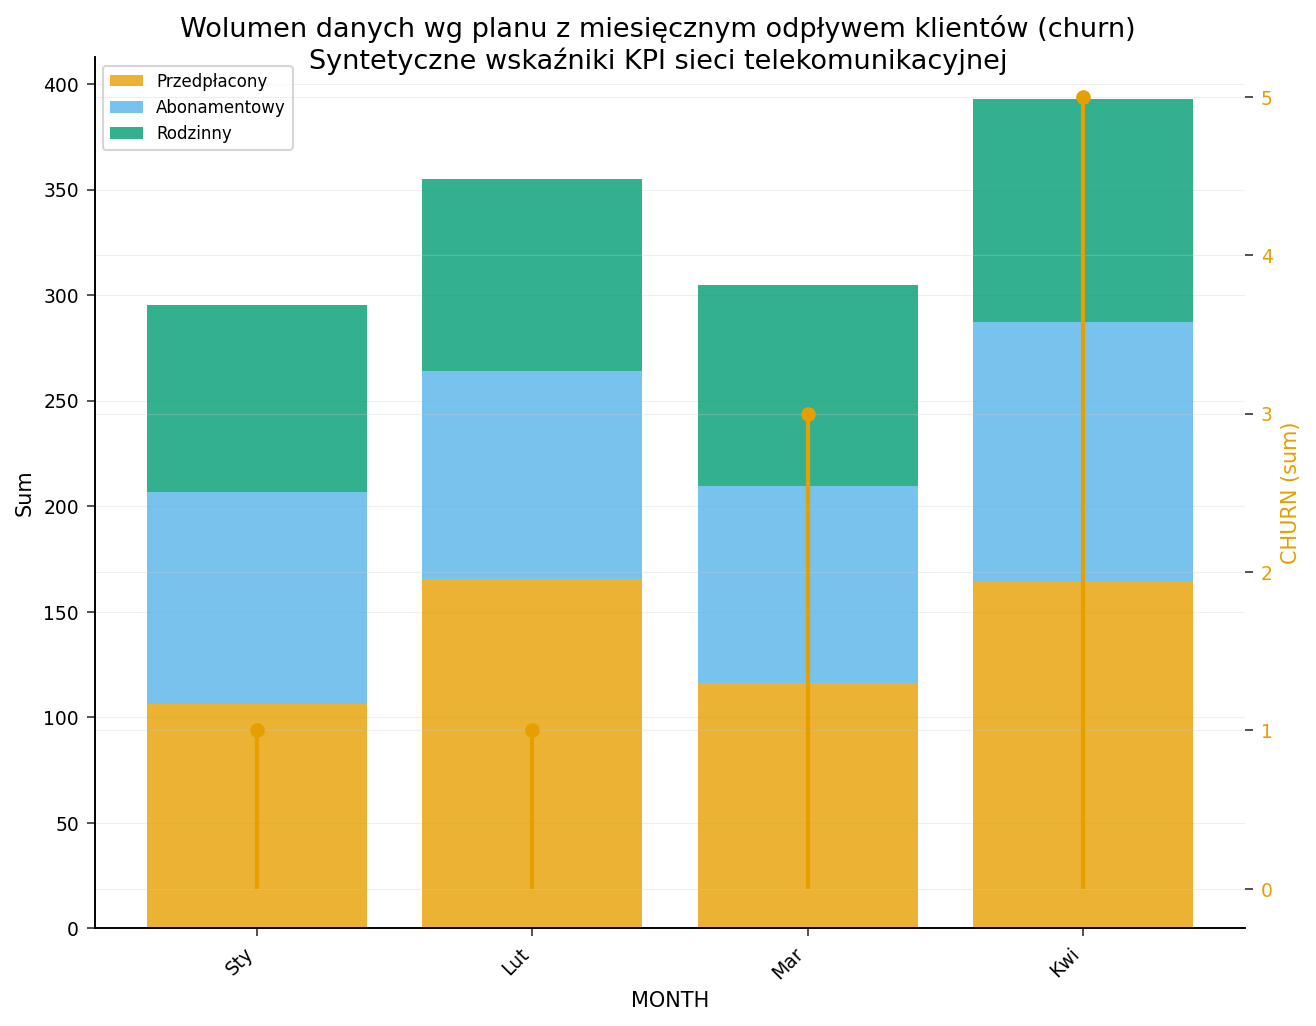

In [3]:
TYTUŁ 'Wolumen danych wg planu z miesięcznym odpływem klientów (churn)';

PROCEDURA gbarline DANE=telco_kpi;
    bar month / SUMVAR=data_gb type=sum SUBGROUP=plan;
    line churn / STAT=sum type=needle;
    ETYKIETA month="Miesiąc" plan="Plan" data_gb="Zużycie danych (GB)" churn="Odpływ klientów";
WYKONAJ;

## Krok 4 — Kontrola prawej osi i znacznika linii

Dla wykresu gotowego do publikacji przypinamy oś wykresu (prawą) do stałego zakresu za pomocą definicji `AXIS` i ją etykietujemy, a następnie wiążemy ją z linią przez `RAXIS=axis2`. Definicja `SYMBOL` nadaje linii ARPU czerwony kropkowany znacznik. Wyświetlamy też sumy słupków nad każdym słupkiem za pomocą `OUTSIDE=sum`.

                                     Łączne zużycie (słupki) a średnie ARPU (linia)                                     
                                   Syntetyczne wskaźniki KPI sieci telekomunikacyjnej                                   




NOTE: Option TITLE changed to Łączne zużycie (słupki) a średnie ARPU (linia).
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


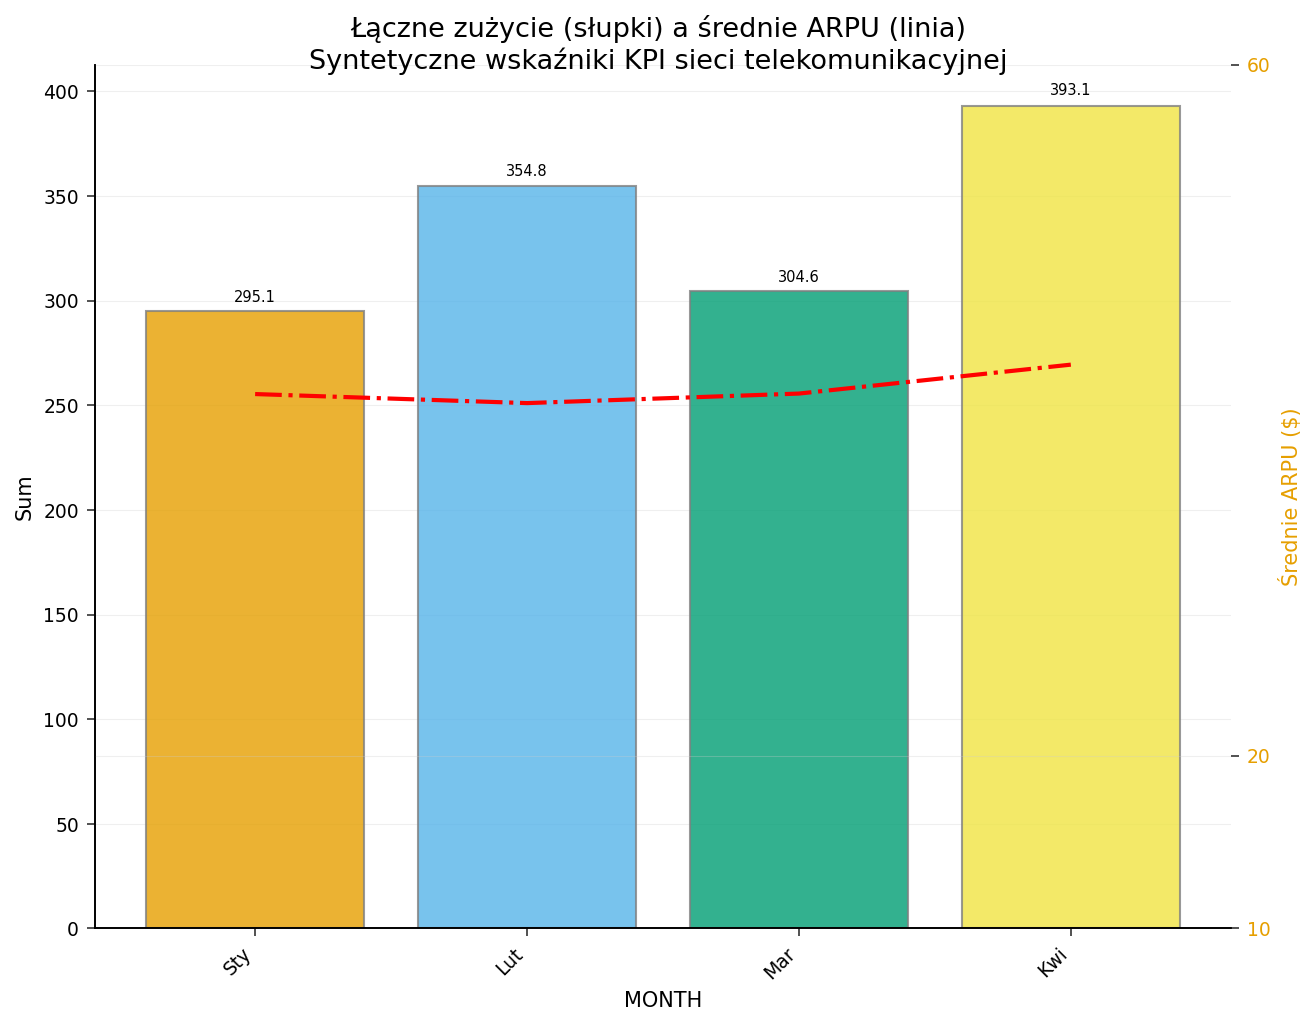

In [4]:
TYTUŁ 'Łączne zużycie (słupki) a średnie ARPU (linia)';

PROCEDURA gbarline DANE=telco_kpi;
    axis2 ORDER=(20 TO 60 WEDŁUG 10) ETYKIETA=('Średnie ARPU ($)');
    symbol1 color=red INTERPOL=JOIN VALUE=dot HEIGHT=1.4;
    bar month / SUMVAR=data_gb type=sum
                outside=sum coutline=gray;
    line arpu / STAT=mean type=JOIN raxis=axis2 SYMBOL=symbol1;
    ETYKIETA month="Miesiąc" data_gb="Zużycie danych (GB)" arpu="ARPU ($)";
WYKONAJ;

## Krok 5 — Wiele nakładek liniowych z niestandardową legendą

`GBARLINE` akceptuje więcej niż jedną instrukcję `LINE`, więc możemy porównać dwa sygnały operacyjne z słupkami zużycia jednocześnie: średnie zgłoszenia serwisowe (`type=join`) i łączny odpływ (`type=needle`). Definicja `LEGEND` umieszczona na dole dokumentuje podgrupy planu.

                                     Trendy zgłoszeń serwisowych i odpływu klientów                                     
                                   Syntetyczne wskaźniki KPI sieci telekomunikacyjnej                                   




NOTE: Option TITLE changed to Trendy zgłoszeń serwisowych i odpływu klientów.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json
NOTE: ODS Graphics is OFF.


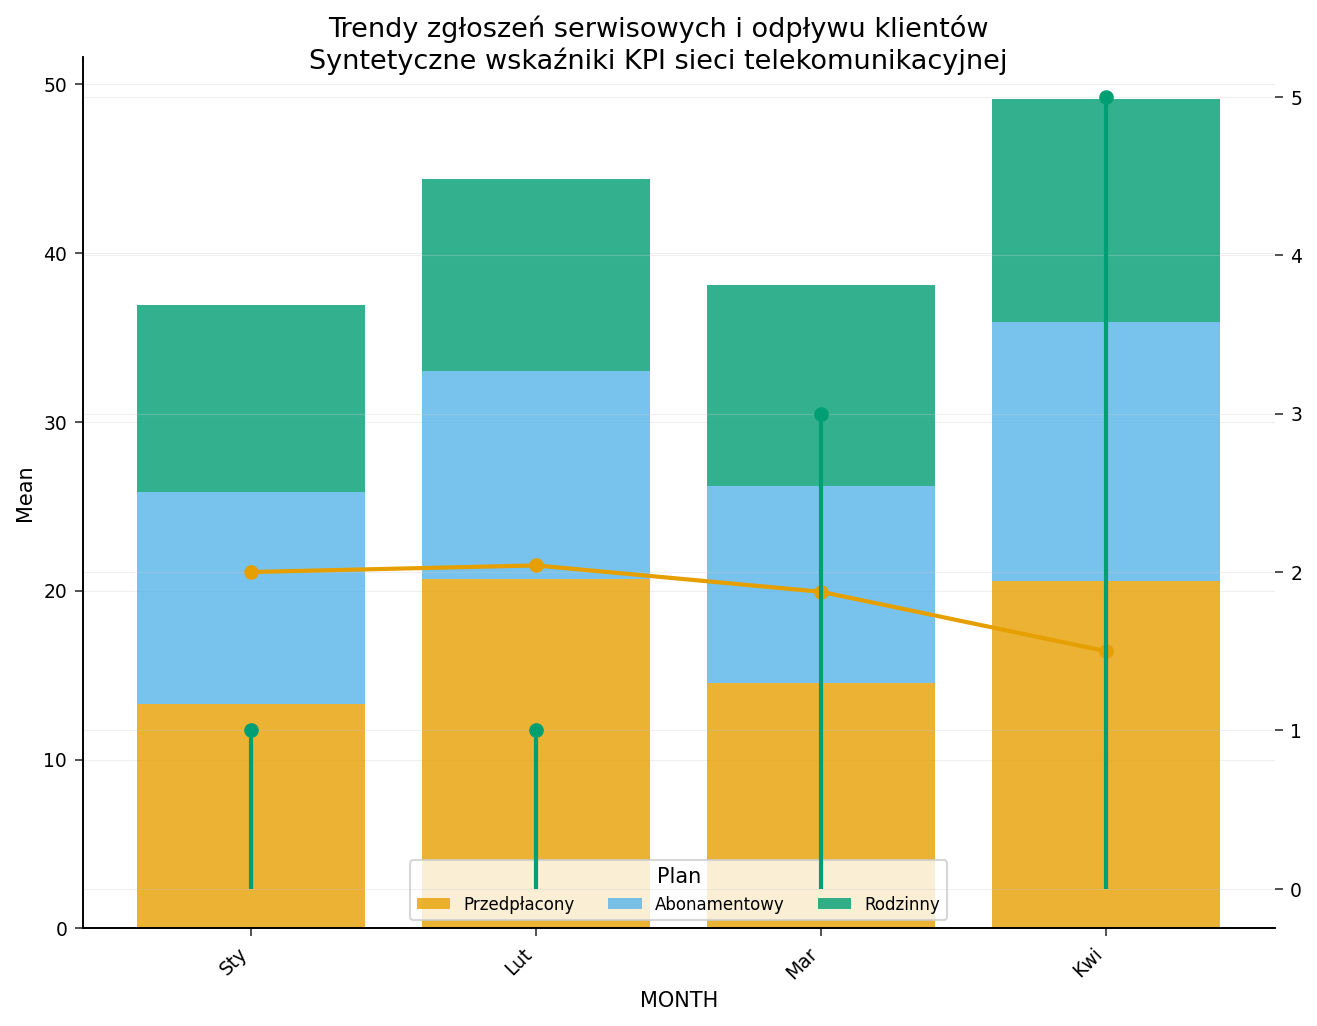

In [5]:
TYTUŁ 'Trendy zgłoszeń serwisowych i odpływu klientów';

PROCEDURA gbarline DANE=telco_kpi;
    legend1 ETYKIETA=('Plan') position=(bottom) ACROSS=3;
    bar month / SUMVAR=data_gb type=mean SUBGROUP=plan
                legend=legend1;
    line tickets / STAT=mean type=JOIN;
    line churn / STAT=sum type=needle;
    ETYKIETA month="Miesiąc" plan="Plan" data_gb="Zużycie danych (GB)"
          tickets="Zgłoszenia serwisowe" churn="Odpływ klientów";
WYKONAJ;

ODS GRAPHICS OFF;

## Interpretacja wyników

W oknie sty–kwi pulpit opowiada spójną historię telekomunikacyjną. **Zużycie danych** (słupki) jest niejednolite miesiąc do miesiąca, ale wykazuje trend wzrostowy, osiągając szczyt w **kwietniu** — średnie zużycie rośnie z ok. 12,3 GB w styczniu do 16,4 GB w kwietniu (Krok 2), a łączny wolumen z 295 GB do 393 GB (etykiety `OUTSIDE=sum` w Kroku 4). **Linia ARPU** nieznacznie spada w lutym, a następnie rośnie do własnego kwietniowego szczytu blisko 42,6 USD, więc operator w coraz większym stopniu monetyzuje dodatkowe zużycie zamiast oddawać je za darmo — prawa oś w Kroku 4 jest przypięta do 20–60 USD, aby ten ruch pozostał czytelny.

Widoki ułożone wg planu (Kroki 3 i 5) ujawniają napięcie segmentowe definiujące operatorów zorientowanych na przedpłatę. **Przedpłacony** (pomarańczowe pasmo) niesie najwięcej gigabajtów ogółem — w przybliżeniu 553 GB na przestrzeni czterech miesięcy wobec 415 GB dla Abonamentowego i 380 GB dla Rodzinnego — a mimo to zarabia **najniższy** średni przychód na użytkownika (ok. 36 USD wobec 41 USD dla Abonamentowego i 47 USD dla Rodzinnego). **Igły odpływu** potwierdzają, gdzie leży ryzyko retencji: zdarzenia odpływu grupują się na poziomach Przedpłacony i Abonamentowy (po 4 zdarzenia w każdym w oknie) i pozostają lżejsze na Rodzinnym (2), a rosną w kierunku kwietnia wraz z ekspansją bazy abonenckiej i zużycia.

Krok 5 nakłada na to obciążenie operacyjne: średnie **zgłoszenia serwisowe** są nieco cięższe wcześnie w okresie i łagodnieją do kwietnia, podczas gdy igły odpływu osiągają szczyt później — rodzaj sygnału, którego wypatruje zespół retencji. Operacyjnie, odczyt wskazuje na skoncentrowanie wydatków retencyjnych na abonentach **Przedpłaconych**, którzy zużywają najszybciej rosnący wycinek wolumenu danych, generując przy tym najmniej przychodu i najwięcej odpływu.

`PROC GBARLINE` jest tu właściwym narzędziem właśnie dlatego, że utrzymuje słupki w skali gigabajtów i linie w skali dolarów/zliczeń na niezależnych osiach, pozwalając czytać każdy KPI na jego własnych warunkach przy zachowaniu wspólnej miesięcznej osi czasu.